## 1 - Imports et configuration


# Classification de navires

Classer des images de navires en niveaux de gris (128×192 px) dans **10 catégories** et produire `test.csv` pour la compétition kaggle.

**Classes :**
```
coastguard_scaled: 0  containership_scaled: 1  corvette_scaled: 2  cruiser_scaled: 3
cv_scaled: 4          destroyer_scaled: 5      methanier_scaled: 6  smallfish_scaled: 7
submarine_scaled: 8   tug_scaled: 9
```

**Structure :**
1. Imports & config
2. Chargement du dataset
3. Analyse (distribution, visualisation)
4. Split stratifié + augmentation
5. Architecture : DeepGAPCNN
6. Fonctions d'entraînement & évaluation
7. Entraînement (DeepGAPCNN de base)
8. Courbes d'apprentissage
9. Analyse détaillée du meilleur modèle
10. Soumission initiale
11. Helpers AMP bf16 / MixUp / CutMix / `train_model_advanced`
12. Améliorations : LS, Aug forte, MixUp, CutMix, TTA, Ensemble
13. Piste A : DeepGAPCNN v2 densifié + multi-seed


In [1]:
!pip install matplotlib seaborn scikit-learn

In [2]:
import os
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision import models

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')


Device : cuda
GPU    : NVIDIA A100-PCIE-40GB


In [3]:
DATA_DIR = Path('./ships24/ships_gray/ships_gray')
TEST_NPY = Path('./ships24/test_images.npy')
SUBMISSION = Path('./test.csv')

CLASS_TO_IDX = {
    'coastguard_scaled': 0, 'containership_scaled': 1, 'corvette_scaled': 2,
    'cruiser_scaled': 3, 'cv_scaled': 4, 'destroyer_scaled': 5,
    'methanier_scaled': 6, 'smallfish_scaled': 7, 'submarine_scaled': 8,
    'tug_scaled': 9,
}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
CLASSES = [IDX_TO_CLASS[i] for i in range(10)]
NUM_CLASSES = len(CLASSES)

IMG_H, IMG_W = 128, 192  # je le sais déjà, mais mis à jour en section 3

BATCH_SIZE = 1024
NUM_EPOCHS = 120
WARMUP_EPOCHS = 8
LR = 2e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 20

print(f'Classes ({NUM_CLASSES}) : {CLASSES}')


Classes (10) : ['coastguard_scaled', 'containership_scaled', 'corvette_scaled', 'cruiser_scaled', 'cv_scaled', 'destroyer_scaled', 'methanier_scaled', 'smallfish_scaled', 'submarine_scaled', 'tug_scaled']


## 2 - Chargement du dataset `ships_gray/`


In [4]:
class ShipsDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.transform = transform
        self.labels = [label for _, label in samples]
        self.images = [Image.open(path).convert("L") for path, _ in samples]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]


def list_all_samples(data_dir, class_to_idx):
    samples = []
    for class_name, class_idx in class_to_idx.items():
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            raise FileNotFoundError(f'Dossier manquant : {class_dir}')
        for p in sorted(class_dir.iterdir()):
            if p.suffix.lower() in ('.jpg', '.jpeg', '.bmp', '.tif', '.tiff'):
                samples.append((str(p), class_idx))
    return samples


all_samples = list_all_samples(DATA_DIR, CLASS_TO_IDX)
print(f'Nombre total d images : {len(all_samples)}')

Nombre total d images : 37980


## 3 - Analyse du dataset


In [5]:
# Vérification des dimensions réelles (sur un échantillon)
sizes = Counter()
for path, _ in all_samples[::len(all_samples) // 200 + 1]:
    with Image.open(path) as im:
        sizes[im.size] += 1

print('Tailles rencontrées (width, height) :')
for sz, n in sizes.most_common():
    print(f'  {sz} : {n}')

(width, height), _ = sizes.most_common(1)[0]
IMG_H, IMG_W = height, width
print(f'\n-> IMG_H={IMG_H}, IMG_W={IMG_W}')


Tailles rencontrées (width, height) :
  (192, 128) : 200

-> IMG_H=128, IMG_W=192


Distribution par classe :
--------------------------------------------------
  0 coastguard_scaled      :   3128  ( 8.24 %)
  1 containership_scaled   :   6266  (16.50 %)
  2 corvette_scaled        :   2676  ( 7.05 %)
  3 cruiser_scaled         :   6251  (16.46 %)
  4 cv_scaled              :   1826  ( 4.81 %)
  5 destroyer_scaled       :   5981  (15.75 %)
  6 methanier_scaled       :   3172  ( 8.35 %)
  7 smallfish_scaled       :   3014  ( 7.94 %)
  8 submarine_scaled       :   2562  ( 6.75 %)
  9 tug_scaled             :   3104  ( 8.17 %)
--------------------------------------------------
  Total                   :  37980


/tmp/ipykernel_1238/510520709.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=9)


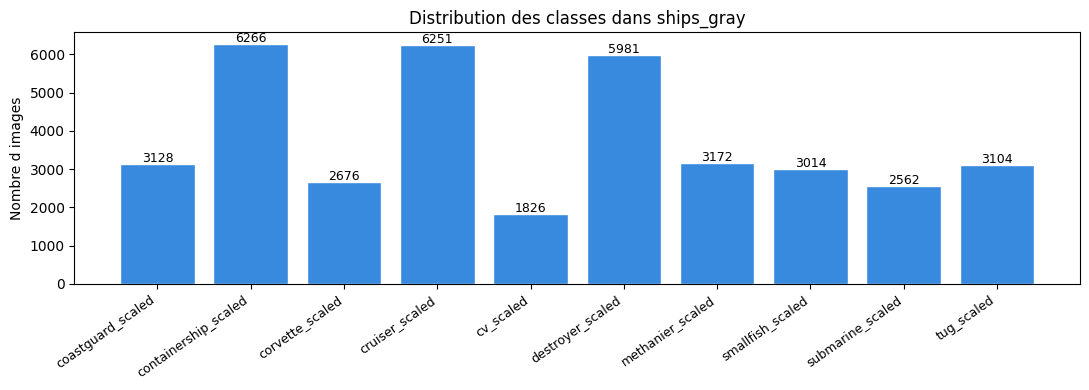

In [6]:
class_counts = Counter([lbl for _, lbl in all_samples])

print('Distribution par classe :')
print('-' * 50)
for cls_idx in range(NUM_CLASSES):
    name = IDX_TO_CLASS[cls_idx]
    n = class_counts[cls_idx]
    pct = 100 * n / len(all_samples)
    print(f'  {cls_idx} {name:<22} : {n:>6}  ({pct:5.2f} %)')
print('-' * 50)
print(f'  Total                   : {len(all_samples):>6}')

fig, ax = plt.subplots(figsize=(11, 4))
counts = [class_counts[i] for i in range(NUM_CLASSES)]
bars = ax.bar(CLASSES, counts, color='#378ADD', edgecolor='white')
ax.set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Nombre d images')
ax.set_title('Distribution des classes dans ships_gray')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, str(c),
            ha='center', fontsize=9)
plt.tight_layout();
plt.show()


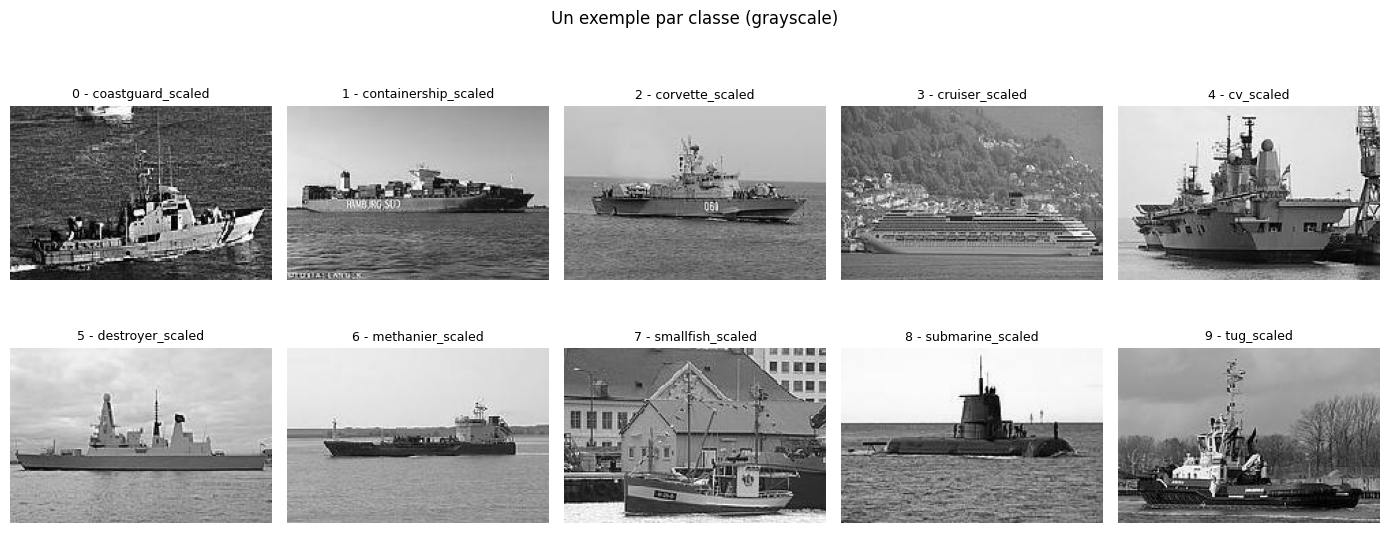

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
rng = np.random.default_rng(SEED)
for ax, cls_idx in zip(axes.flat, range(NUM_CLASSES)):
    indexes = [i for i, (_, l) in enumerate(all_samples) if l == cls_idx]
    path, _ = all_samples[rng.choice(indexes)]
    ax.imshow(Image.open(path).convert('L'), cmap='gray')
    ax.set_title(f'{cls_idx} - {IDX_TO_CLASS[cls_idx]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Un exemple par classe (grayscale)', fontsize=12)
plt.tight_layout();
plt.show()

tatementDown)jjjj

## 4 - Split stratifié + data augmentation


In [8]:
all_labels = np.array([l for _, l in all_samples])

idx_trainval, idx_test = train_test_split(
    np.arange(len(all_samples)), test_size=0.10,
    random_state=SEED, stratify=all_labels,
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=1 / 9,
    random_state=SEED, stratify=all_labels[idx_trainval],
)

print(f'Train : {len(idx_train):>6}  |  Val : {len(idx_val):>6}  |  Test : {len(idx_test):>6}')

print('\nDistribution par classe :')
print(f'{"classe":<22} {"train":>8} {"val":>8} {"test":>8}')
for c in range(NUM_CLASSES):
    p_tr = 100 * (all_labels[idx_train] == c).mean()
    p_va = 100 * (all_labels[idx_val] == c).mean()
    p_te = 100 * (all_labels[idx_test] == c).mean()
    print(f'{IDX_TO_CLASS[c]:<22} {p_tr:7.2f}% {p_va:7.2f}% {p_te:7.2f}%')


Train :  30384  |  Val :   3798  |  Test :   3798

Distribution par classe :
classe                    train      val     test
coastguard_scaled         8.23%    8.24%    8.24%
containership_scaled     16.50%   16.51%   16.51%
corvette_scaled           7.04%    7.06%    7.06%
cruiser_scaled           16.46%   16.46%   16.46%
cv_scaled                 4.81%    4.82%    4.82%
destroyer_scaled         15.75%   15.75%   15.75%
methanier_scaled          8.35%    8.35%    8.35%
smallfish_scaled          7.94%    7.93%    7.93%
submarine_scaled          6.75%    6.74%    6.74%
tug_scaled                8.18%    8.16%    8.16%


In [9]:
stats_transform = T.Compose([
    T.Resize((IMG_H, IMG_W)), T.ToTensor()
])

stats_ds = ShipsDataset(
    [all_samples[i] for i in idx_train], transform=stats_transform
)

stats_loader = DataLoader(stats_ds, batch_size=256, shuffle=False, num_workers=0)

mean, n_pixels = 0.0, 0
for imgs, _ in stats_loader:
    b, c, h, w = imgs.shape
    mean += imgs.sum(dim=[0, 2, 3])
    n_pixels += b * h * w
mean /= n_pixels

std = 0.0
for imgs, _ in stats_loader:
    std += ((imgs - mean[None, :, None, None]) ** 2).sum(dim=[0, 2, 3])
std = torch.sqrt(std / n_pixels)

MEAN = tuple(mean.tolist())
STD = tuple(std.tolist())
print(f'Mean : {MEAN}')
print(f'Std  : {STD}')


Mean : (0.5419638752937317,)
Std  : (0.24195732176303864,)


In [10]:
transform_train = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.92, 1.08)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.1)),
])

transform_eval = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

train_ds = ShipsDataset([all_samples[i] for i in idx_train], transform=transform_train)
val_ds = ShipsDataset([all_samples[i] for i in idx_val], transform=transform_eval)
test_ds = ShipsDataset([all_samples[i] for i in idx_test], transform=transform_eval)

num_workers = min(os.cpu_count() - 1, 16) if device == 'cuda' else 0
pin = (device == 'cuda')
persistent = (num_workers > 0)

trainloader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=num_workers, pin_memory=pin,
                         persistent_workers=persistent, prefetch_factor=4 if persistent else None)
valloader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=num_workers, pin_memory=pin,
                       persistent_workers=persistent, prefetch_factor=4 if persistent else None)
testloader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=num_workers, pin_memory=pin,
                        persistent_workers=persistent, prefetch_factor=4 if persistent else None)

imgs, lbls = next(iter(trainloader))
print(f'Batch train : {imgs.shape}  range [{imgs.min():.2f}, {imgs.max():.2f}]')


Batch train : torch.Size([1024, 1, 128, 192])  range [-2.24, 1.89]


## 5 - Architecture : DeepGAPCNN


In [11]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, pool=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.pool = nn.MaxPool2d(2, 2) if pool else nn.Identity()

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.pool(x)


class DeepGAPCNN(nn.Module):
    def __init__(self, num_classes=10, in_channels=1, dropout=0.3):
        super().__init__()
        self.block1 = ConvBlock(in_channels, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.block4 = ConvBlock(128, 256)
        self.block5 = ConvBlock(256, 512, pool=False)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.block5(self.block4(self.block3(self.block2(self.block1(x)))))
        return self.fc(self.dropout(torch.flatten(self.gap(x), 1)))


m_test = DeepGAPCNN()
with torch.no_grad():
    y = m_test(torch.randn(2, 1, IMG_H, IMG_W))
print(f'DeepGAPCNN | output : {tuple(y.shape)} | params : {count_params(m_test):,}')


DeepGAPCNN | output : (2, 10) | params : 4,718,762


## 6 - Fonctions d'entraînement et d'évaluation


In [12]:
# Poids de classes pour compenser le déséquilibre dans CrossEntropyLoss
class_counts_train = np.bincount([all_samples[i][1] for i in idx_train],
                                 minlength=NUM_CLASSES)
class_weights = len(idx_train) / (NUM_CLASSES * class_counts_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print('Poids par classe :')
for i, (n, w) in enumerate(zip(class_counts_train, class_weights.cpu().numpy())):
    print(f'  {i} {IDX_TO_CLASS[i]:<22} n={n:>5}  w={w:.3f}')


Poids par classe :
  0 coastguard_scaled      n= 2502  w=1.214
  1 containership_scaled   n= 5012  w=0.606
  2 corvette_scaled        n= 2140  w=1.420
  3 cruiser_scaled         n= 5001  w=0.608
  4 cv_scaled              n= 1460  w=2.081
  5 destroyer_scaled       n= 4785  w=0.635
  6 methanier_scaled       n= 2538  w=1.197
  7 smallfish_scaled       n= 2412  w=1.260
  8 submarine_scaled       n= 2050  w=1.482
  9 tug_scaled             n= 2484  w=1.223


In [13]:
def train_model(model, trainloader, valloader, num_epochs=NUM_EPOCHS, lr=LR,
                weight_decay=WEIGHT_DECAY, device='cpu', model_name='model',
                class_weights=None, patience=PATIENCE, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    use_amp = (device != 'cpu') and torch.cuda.is_bf16_supported()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state, epochs_no_imp = 0.0, None, 0
    t0 = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in trainloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, pred = outputs.max(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = 100 * correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
            for images, labels in valloader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * images.size(0)
                v_correct += (outputs.max(1)[1] == labels).sum().item()
                v_total += labels.size(0)
        val_loss = v_loss / v_total
        val_acc = 100 * v_correct / v_total

        scheduler.step()
        for k, v in [('train_loss', train_loss), ('train_acc', train_acc),
                     ('val_loss', val_loss), ('val_acc', val_acc)]:
            history[k].append(v)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_imp = 0
        else:
            epochs_no_imp += 1

        if verbose:
            marker = '  *' if improved else ''
            print(f'[{model_name}] ep {epoch + 1:2d}/{num_epochs} | '
                  f'train loss={train_loss:.4f} acc={train_acc:5.2f}% | '
                  f'val loss={val_loss:.4f} acc={val_acc:5.2f}%{marker}')

        if epochs_no_imp >= patience:
            print(f'  -> Early stopping epoch {epoch + 1}')
            break

    print(f'\n[{model_name}] {time.time() - t0:.1f}s | best val = {best_val_acc:.2f}%')
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_state


def evaluate(model, loader, device):
    use_amp = (device != 'cpu') and torch.cuda.is_bf16_supported()
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            _, pred = outputs.max(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return 100 * correct / total, np.array(all_preds), np.array(all_labels)


## 7 - Entraînement de DeepGAPCNN


In [14]:
print('=' * 70)
print('DeepGAPCNN — 30 epochs, Adam, CosineAnnealingLR, batch=1024')
print('=' * 70)

deep_model = DeepGAPCNN(num_classes=NUM_CLASSES, in_channels=1, dropout=0.3)
hist_deep, _ = train_model(
    deep_model, trainloader, valloader,
    num_epochs=30, lr=LR, weight_decay=WEIGHT_DECAY,
    device=device, model_name='DeepGAPCNN',
    class_weights=class_weights, patience=PATIENCE,
)
acc_deep, _, _ = evaluate(deep_model, testloader, device)
print(f'\n-> Test accuracy DeepGAPCNN = {acc_deep:.2f}%')
torch.save(deep_model.state_dict(), 'model_DeepGAPCNN.pth')


DeepGAPCNN — 30 epochs, Adam, CosineAnnealingLR, batch=1024
[DeepGAPCNN] ep  1/30 | train loss=2.0993 acc=25.68% | val loss=1.9312 acc=35.44%  *
[DeepGAPCNN] ep  2/30 | train loss=1.7546 acc=40.52% | val loss=1.7715 acc=43.42%  *
[DeepGAPCNN] ep  3/30 | train loss=1.4536 acc=52.47% | val loss=2.1584 acc=33.78%
[DeepGAPCNN] ep  4/30 | train loss=1.2210 acc=59.66% | val loss=2.6113 acc=40.07%
[DeepGAPCNN] ep  5/30 | train loss=1.0639 acc=64.72% | val loss=2.5895 acc=48.03%  *
[DeepGAPCNN] ep  6/30 | train loss=0.9287 acc=69.74% | val loss=2.2144 acc=50.21%  *
[DeepGAPCNN] ep  7/30 | train loss=0.8166 acc=73.52% | val loss=0.9304 acc=68.09%  *
[DeepGAPCNN] ep  8/30 | train loss=0.7318 acc=76.04% | val loss=1.0821 acc=69.01%  *
[DeepGAPCNN] ep  9/30 | train loss=0.6597 acc=78.43% | val loss=1.2015 acc=68.01%
[DeepGAPCNN] ep 10/30 | train loss=0.6090 acc=80.29% | val loss=0.8232 acc=75.99%  *
[DeepGAPCNN] ep 11/30 | train loss=0.5426 acc=82.76% | val loss=0.6339 acc=80.46%  *
[DeepGAPCNN] e

## 8 - Courbes d'apprentissage


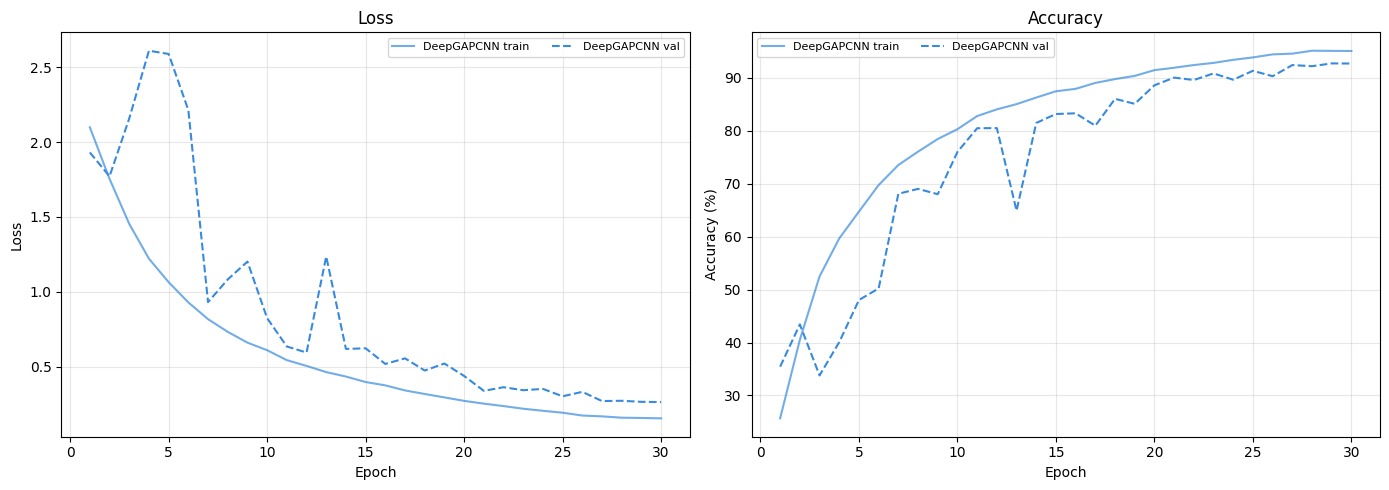

In [15]:
def plot_history(histories, names, figsize=(14, 5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    colors = ['#378ADD', '#E24B4A', '#2EA84F', '#EF9F27', '#8C43BC', '#F08030', '#30C8C8']
    for h, name, c in zip(histories, names, colors):
        ep = range(1, len(h['train_loss']) + 1)
        ax1.plot(ep, h['train_loss'], '-', color=c, label=f'{name} train', alpha=0.7)
        ax1.plot(ep, h['val_loss'], '--', color=c, label=f'{name} val')
        ax2.plot(ep, h['train_acc'], '-', color=c, label=f'{name} train', alpha=0.7)
        ax2.plot(ep, h['val_acc'], '--', color=c, label=f'{name} val')
    for ax, ylab, title in [(ax1, 'Loss', 'Loss'), (ax2, 'Accuracy (%)', 'Accuracy')]:
        ax.set_xlabel('Epoch');
        ax.set_ylabel(ylab);
        ax.set_title(title)
        ax.grid(alpha=0.3);
        ax.legend(fontsize=8, ncol=2)
    plt.tight_layout();
    plt.show()


if globals().get('hist_deep'):
    plot_history([hist_deep], ['DeepGAPCNN'])


In [16]:
# Tableau comparatif
results = {}
for name, hist_key, model_obj in [
    ('DeepGAPCNN', 'hist_deep', globals().get('deep_model')),
]:
    hist = globals().get(hist_key)
    if hist is not None and model_obj is not None:
        acc, _, _ = evaluate(model_obj, testloader, device)
        results[name] = {
            'params': count_params(model_obj),
            'best_val': max(hist['val_acc']),
            'test_acc': acc,
            'overfit': hist['train_acc'][-1] - hist['val_acc'][-1],
        }

print(f'{"Modèle":<16} {"Params":>12} {"Best val":>10} {"Test acc":>10} {"Overfit":>10}')
print('-' * 62)
for name, r in results.items():
    print(f'{name:<16} {r["params"]:>12,} {r["best_val"]:>9.2f}% {r["test_acc"]:>9.2f}% {r["overfit"]:>9.2f}%')


Modèle                 Params   Best val   Test acc    Overfit
--------------------------------------------------------------
DeepGAPCNN          4,718,762     92.71%     92.21%      2.37%


## 9 - Analyse détaillée du meilleur modèle


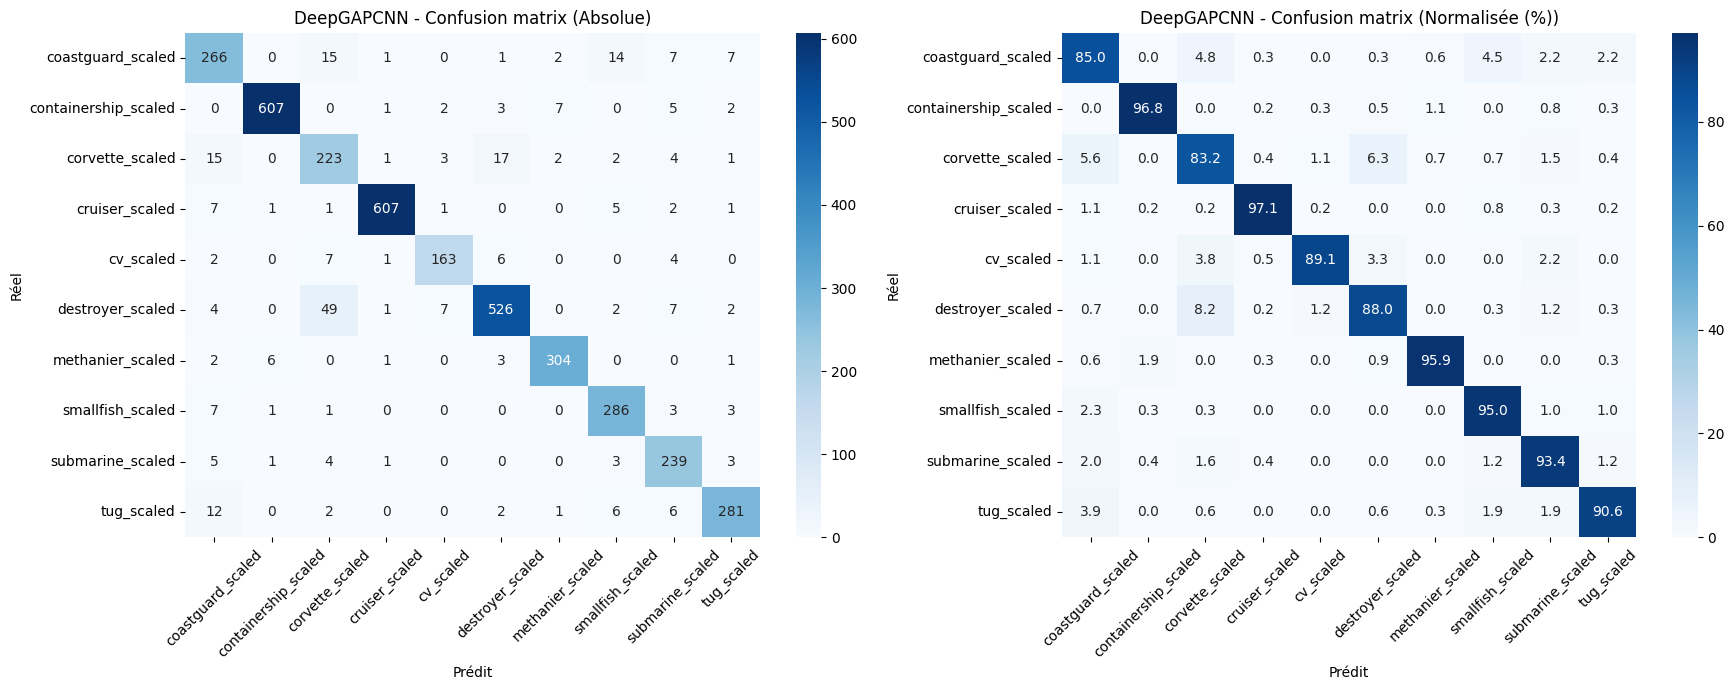

In [17]:
BEST_MODEL = deep_model
BEST_NAME = 'DeepGAPCNN'

_, preds, labels = evaluate(BEST_MODEL, testloader, device)
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in [
    (axes[0], cm, 'd', 'Absolue'),
    (axes[1], cm_norm, '.1f', 'Normalisée (%)'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f'{BEST_NAME} - Confusion matrix ({title})')
    ax.set_xlabel('Prédit');
    ax.set_ylabel('Réel')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout();
plt.show()


In [18]:
print(f'Rapport de classification - {BEST_NAME}')
print('=' * 70)
print(classification_report(labels, preds, target_names=CLASSES, digits=3))


Rapport de classification - DeepGAPCNN
                      precision    recall  f1-score   support

   coastguard_scaled      0.831     0.850     0.840       313
containership_scaled      0.985     0.968     0.977       627
     corvette_scaled      0.738     0.832     0.782       268
      cruiser_scaled      0.989     0.971     0.980       625
           cv_scaled      0.926     0.891     0.908       183
    destroyer_scaled      0.943     0.880     0.910       598
    methanier_scaled      0.962     0.959     0.961       317
    smallfish_scaled      0.899     0.950     0.924       301
    submarine_scaled      0.863     0.934     0.897       256
          tug_scaled      0.934     0.906     0.920       310

            accuracy                          0.922      3798
           macro avg      0.907     0.914     0.910      3798
        weighted avg      0.925     0.922     0.923      3798



In [19]:
torch.save(deep_model.state_dict(), 'model_DeepGAPCNN.pth')
print(f'Sauvegardé : model_DeepGAPCNN.pth  (test acc = {acc_deep:.2f}%)')


Sauvegardé : model_DeepGAPCNN.pth  (test acc = 92.21%)


## 10 - Prédiction sur `test.npy` et génération de `test.csv`

In [20]:
def load_test_npy(path):
    X = np.load(path)
    print(f'test.npy shape brute : {X.shape}, dtype : {X.dtype}')
    X = X.astype(np.float32) / 255
    print(f'-> après norm : shape={X.shape}, range=[{X.min():.3f}, {X.max():.3f}]')
    return torch.from_numpy(X)


test_images = load_test_npy(TEST_NPY)


test.npy shape brute : (4224, 128, 192), dtype : uint8
-> après norm : shape=(4224, 128, 192), range=[0.000, 1.000]


In [23]:
def load_test_npy(path):
    """Charge test.npy et renvoie un tenseur (N, 1, H, W) float32 non normalisé (dans [0, 1])."""
    arr = np.load(path)
    print(f"test.npy shape brute = {arr.shape}, dtype = {arr.dtype}")

    # Cas 1 : (N, H, W) -> on ajoute un axe canal
    if arr.ndim == 3:
        arr = arr[:, None, :, :]  # (N, 1, H, W)

    # Cas 2 : (N, H, W, C) -> on passe en (N, C, H, W)
    elif arr.ndim == 4 and arr.shape[-1] in (1, 3):
        arr = arr.transpose(0, 3, 1, 2)  # (N, C, H, W)

    # Cas 3 : déjà (N, C, H, W) -> ok

    # Si C=3, on convertit en 1 canal par moyenne (luminance)
    if arr.shape[1] == 3:
        arr = arr.mean(axis=1, keepdims=True)

    # Conversion en float32 dans [0, 1]
    arr = arr.astype(np.float32)
    if arr.max() > 1.5:  # probablement en [0, 255]
        arr = arr / 255.0

    print(f"-> après prétraitement : shape = {arr.shape}, dtype = {arr.dtype}, "
          f"range = [{arr.min():.3f}, {arr.max():.3f}]")
    return torch.from_numpy(arr)


test_images = load_test_npy(TEST_NPY)  # tensor (N, 1, H, W) in [0, 1]

test.npy shape brute = (4224, 128, 192), dtype = uint8
-> après prétraitement : shape = (4224, 1, 128, 192), dtype = float32, range = [0.000, 1.000]


In [26]:
y_pred = predict_from_npy(deep_model, test_images, device=device, batch_size=128)

submission = pd.DataFrame({'ID': np.arange(len(y_pred)), 'Category': y_pred.astype(int)})
submission.to_csv(SUBMISSION, index=False)
print(f'Fichier écrit : {SUBMISSION.resolve()}')
print(submission.head(10))


Fichier écrit : /home/test.csv
   ID  Category
0   0         7
1   1         1
2   2         1
3   3         4
4   4         1
5   5         1
6   6         4
7   7         3
8   8         8
9   9         0


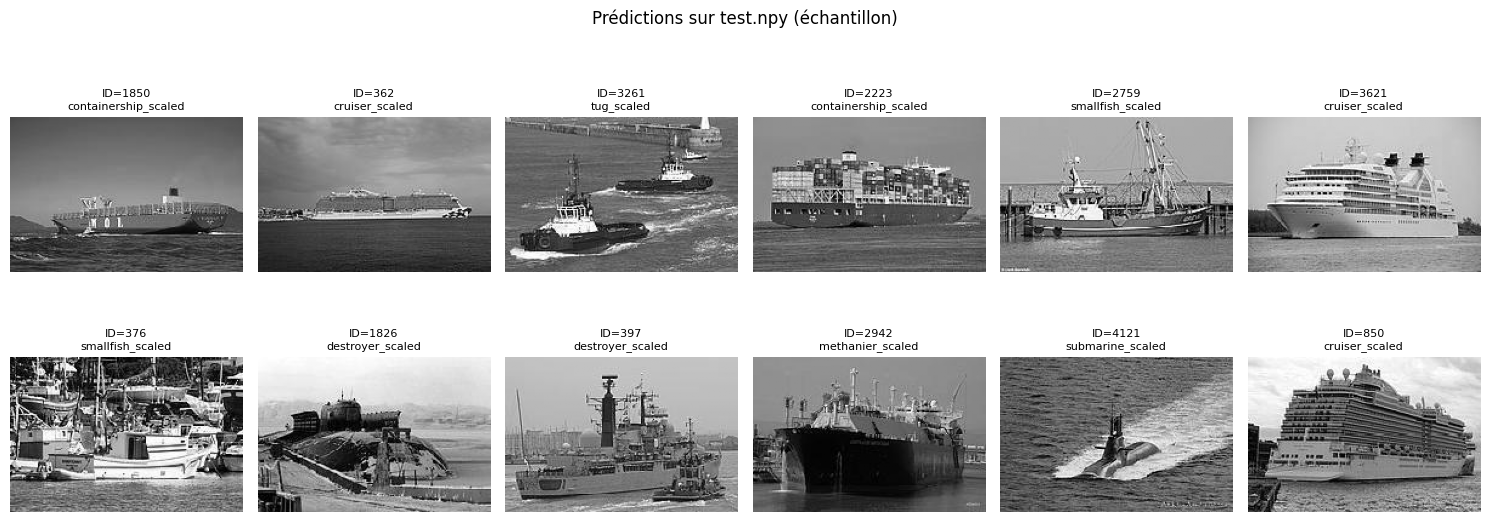

In [27]:
fig, axes = plt.subplots(2, 6, figsize=(15, 6))
idx_sample = np.random.default_rng(SEED).choice(len(test_images), 12, replace=False)
for ax, i in zip(axes.flat, idx_sample):
    ax.imshow(test_images[i, 0].numpy(), cmap='gray')
    ax.set_title(f'ID={i}\n{IDX_TO_CLASS[int(y_pred[i])]}', fontsize=8)
    ax.axis('off')
plt.suptitle('Prédictions sur test.npy (échantillon)')
plt.tight_layout();
plt.show()


## 11 - Helpers : AMP bf16, MixUp, CutMix, `train_model_advanced`


In [28]:
USE_AMP = (device == 'cuda')
AMP_DTYPE = torch.bfloat16
print(f'AMP actif : {USE_AMP}  |  dtype : {AMP_DTYPE}')


AMP actif : True  |  dtype : torch.bfloat16


In [29]:
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1.0 - lam) * x[index], y, y[index], lam


def rand_bbox(size, lam):
    _, _, H, W = size
    cut_rat = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_rat), int(W * cut_rat)
    cy, cx = np.random.randint(H), np.random.randint(W)
    y1 = np.clip(cy - cut_h // 2, 0, H);
    y2 = np.clip(cy + cut_h // 2, 0, H)
    x1 = np.clip(cx - cut_w // 2, 0, W);
    x2 = np.clip(cx + cut_w // 2, 0, W)
    return y1, y2, x1, x2


def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    y1, y2, x1, x2 = rand_bbox(x.size(), lam)
    x_mixed = x.clone()
    x_mixed[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam = 1.0 - ((y2 - y1) * (x2 - x1) / (x.size(-1) * x.size(-2)))
    return x_mixed, y, y[index], lam


In [30]:
def train_model_advanced(model, trainloader, valloader, num_epochs=30, lr=1e-3,
                         weight_decay=1e-4, device='cpu', model_name='model',
                         class_weights=None, label_smoothing=0.0,
                         mix_mode=None, mix_alpha=0.2,
                         patience=8, verbose=True, use_amp=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    val_criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    amp_enabled = use_amp and (device == 'cuda')

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state, epochs_no_imp = 0.0, None, 0
    t0 = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in trainloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            if mix_mode is None:
                mix_this = None
            elif mix_mode == 'both':
                mix_this = 'mixup' if np.random.rand() < 0.5 else 'cutmix'
            else:
                mix_this = mix_mode

            with torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
                if mix_this == 'mixup':
                    mixed, y_a, y_b, lam = mixup_data(images, labels, mix_alpha)
                    outputs = model(mixed)
                    loss = lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)
                elif mix_this == 'cutmix':
                    mixed, y_a, y_b, lam = cutmix_data(images, labels, mix_alpha)
                    outputs = model(mixed)
                    loss = lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, pred = outputs.max(1)
            if mix_this is not None:
                correct += (lam * (pred == y_a).float()
                            + (1.0 - lam) * (pred == y_b).float()).sum().item()
            else:
                correct += (pred == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
            for images, labels in valloader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = val_criterion(outputs, labels)
                v_loss += loss.item() * images.size(0)
                v_correct += (outputs.max(1)[1] == labels).sum().item()
                v_total += labels.size(0)
        val_loss = v_loss / v_total
        val_acc = 100 * v_correct / v_total

        scheduler.step()
        for k, v in [('train_loss', train_loss), ('train_acc', train_acc),
                     ('val_loss', val_loss), ('val_acc', val_acc)]:
            history[k].append(v)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_imp = 0
        else:
            epochs_no_imp += 1

        if verbose:
            marker = '  *' if improved else ''
            print(f'[{model_name}] ep {epoch + 1:2d}/{num_epochs} | '
                  f'train loss={train_loss:.4f} acc={train_acc:5.2f}% | '
                  f'val loss={val_loss:.4f} acc={val_acc:5.2f}%{marker}')

        if epochs_no_imp >= patience:
            print(f'  -> Early stopping epoch {epoch + 1}')
            break

    print(f'\n[{model_name}] {time.time() - t0:.1f}s | best val = {best_val_acc:.2f}%')
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_state


improvements_results = {}
improvements_models = {}


## 12 - Améliorations mono-modèle

On améliore DeepGAPCNN par étapes :
1. **12.1** — Label smoothing (ε=0.1)
2. **12.2** — Augmentation forte
3. **12.3** — MixUp (α=0.2)
4. **12.4** — CutMix (α=1.0)
5. **12.5** — Analyse de diversité
6. **12.6** — Test-Time Augmentation
7. **12.7** — Ensembling raisonné
8. **12.8** — Soumission finale


## 12.1 - Label smoothing (ε = 0.1)


In [31]:
print('=' * 70);
print('12.1 - DeepGAPCNN + Label Smoothing (ε=0.1)');
print('=' * 70)

model_ls = DeepGAPCNN(num_classes=NUM_CLASSES, in_channels=1, dropout=0.3)
hist_ls, _ = train_model_advanced(
    model_ls, trainloader, valloader,
    num_epochs=30, lr=1e-3, weight_decay=1e-4,
    device=device, model_name='DeepGAPCNN+LS',
    class_weights=class_weights,
    label_smoothing=0.1, mix_mode=None,
    patience=8, use_amp=USE_AMP,
)
acc_ls, _, _ = evaluate(model_ls, testloader, device)
print(f'\n*** DeepGAPCNN + LS = {acc_ls:.2f}%  (baseline = 93.13%) ***')

improvements_results['LS'] = acc_ls
improvements_models['LS'] = model_ls

12.1 - DeepGAPCNN + Label Smoothing (ε=0.1)
[DeepGAPCNN+LS] ep  1/30 | train loss=2.1345 acc=27.47% | val loss=2.0152 acc=24.35%  *
[DeepGAPCNN+LS] ep  2/30 | train loss=1.8081 acc=46.39% | val loss=1.8914 acc=37.47%  *
[DeepGAPCNN+LS] ep  3/30 | train loss=1.5524 acc=58.19% | val loss=1.4461 acc=49.68%  *
[DeepGAPCNN+LS] ep  4/30 | train loss=1.3738 acc=65.96% | val loss=1.0628 acc=64.11%  *
[DeepGAPCNN+LS] ep  5/30 | train loss=1.2496 acc=72.02% | val loss=1.3812 acc=58.29%
[DeepGAPCNN+LS] ep  6/30 | train loss=1.1677 acc=75.57% | val loss=1.2351 acc=57.40%
[DeepGAPCNN+LS] ep  7/30 | train loss=1.1066 acc=78.69% | val loss=0.6754 acc=80.54%  *
[DeepGAPCNN+LS] ep  8/30 | train loss=1.0440 acc=81.54% | val loss=0.8798 acc=73.20%
[DeepGAPCNN+LS] ep  9/30 | train loss=1.0102 acc=82.98% | val loss=0.6854 acc=79.15%
[DeepGAPCNN+LS] ep 10/30 | train loss=0.9744 acc=84.69% | val loss=1.4315 acc=56.42%
[DeepGAPCNN+LS] ep 11/30 | train loss=0.9601 acc=84.92% | val loss=0.5742 acc=84.44%  *
[De

## 12.2 - Augmentation forte

In [32]:
transform_train_strong = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=15, translate=(0.10, 0.10), scale=(0.82, 1.18), shear=5),
    T.RandomPerspective(distortion_scale=0.15, p=0.3),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.5, scale=(0.02, 0.20), ratio=(0.3, 3.3)),
])

train_ds_strong = ShipsDataset([all_samples[i] for i in idx_train],
                               transform=transform_train_strong)
trainloader_strong = DataLoader(train_ds_strong, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=num_workers, pin_memory=pin,
                                persistent_workers=persistent, prefetch_factor=4 if persistent else None)


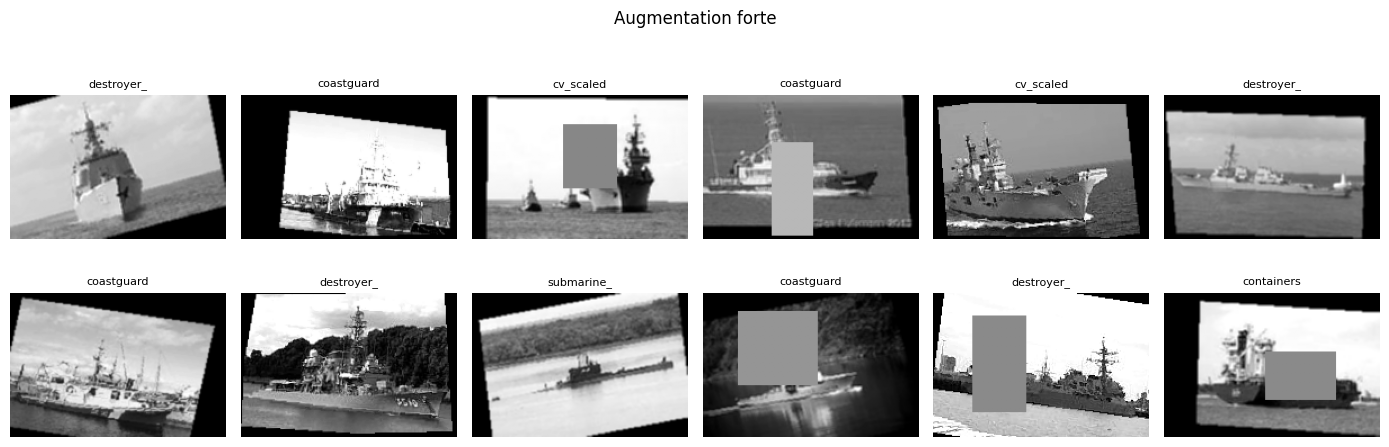

In [33]:
imgs, lbls = next(iter(trainloader_strong))
inv_mean = torch.tensor(MEAN).view(-1, 1, 1)
inv_std = torch.tensor(STD).view(-1, 1, 1)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, img, lbl in zip(axes.flat, imgs[:12], lbls[:12]):
    img_vis = (img * inv_std + inv_mean).clamp(0, 1).squeeze().numpy()
    ax.imshow(img_vis, cmap='gray')
    ax.set_title(CLASSES[lbl.item()][:10], fontsize=8);
    ax.axis('off')
plt.suptitle('Augmentation forte');
plt.tight_layout();
plt.show()


In [34]:
print('=' * 70);
print('12.2 - DeepGAPCNN + LS + Strong Aug');
print('=' * 70)

model_aug = DeepGAPCNN(num_classes=NUM_CLASSES, in_channels=1, dropout=0.3)
hist_aug, _ = train_model_advanced(
    model_aug, trainloader_strong, valloader,
    num_epochs=35, lr=1e-3, weight_decay=1e-4,
    device=device, model_name='DeepGAPCNN+AUG',
    class_weights=class_weights,
    label_smoothing=0.1, mix_mode=None,
    patience=10, use_amp=USE_AMP,
)
acc_aug, _, _ = evaluate(model_aug, testloader, device)
print(f'\n*** DeepGAPCNN + LS + Aug = {acc_aug:.2f}%  (+LS = {improvements_results["LS"]:.2f}%) ***')

improvements_results['AUG'] = acc_aug
improvements_models['AUG'] = model_aug

12.2 - DeepGAPCNN + LS + Strong Aug
[DeepGAPCNN+AUG] ep  1/35 | train loss=2.2935 acc=17.46% | val loss=2.0749 acc=25.96%  *
[DeepGAPCNN+AUG] ep  2/35 | train loss=2.1143 acc=29.30% | val loss=1.8091 acc=36.73%  *
[DeepGAPCNN+AUG] ep  3/35 | train loss=1.9718 acc=38.79% | val loss=2.0079 acc=30.23%
[DeepGAPCNN+AUG] ep  4/35 | train loss=1.7776 acc=48.60% | val loss=2.2081 acc=34.62%
[DeepGAPCNN+AUG] ep  5/35 | train loss=1.6262 acc=55.42% | val loss=1.7886 acc=39.68%  *
[DeepGAPCNN+AUG] ep  6/35 | train loss=1.4986 acc=61.26% | val loss=1.4613 acc=51.61%  *
[DeepGAPCNN+AUG] ep  7/35 | train loss=1.4236 acc=64.66% | val loss=1.0570 acc=61.06%  *
[DeepGAPCNN+AUG] ep  8/35 | train loss=1.3409 acc=67.85% | val loss=0.9149 acc=69.59%  *
[DeepGAPCNN+AUG] ep  9/35 | train loss=1.2827 acc=70.54% | val loss=0.9091 acc=70.25%  *
[DeepGAPCNN+AUG] ep 10/35 | train loss=1.2433 acc=72.71% | val loss=0.7761 acc=74.09%  *
[DeepGAPCNN+AUG] ep 11/35 | train loss=1.2004 acc=74.63% | val loss=0.7404 acc=7

## 12.3 - MixUp (α = 0.2)


In [35]:
print('=' * 70);
print('12.3 - DeepGAPCNN + LS + Aug + MixUp (α=0.2)');
print('=' * 70)

model_mixup = DeepGAPCNN(num_classes=NUM_CLASSES, in_channels=1, dropout=0.3)
hist_mixup, _ = train_model_advanced(
    model_mixup, trainloader_strong, valloader,
    num_epochs=40, lr=1e-3, weight_decay=1e-4,
    device=device, model_name='DeepGAPCNN+MIX',
    class_weights=class_weights,
    label_smoothing=0.1, mix_mode='mixup', mix_alpha=0.2,
    patience=12, use_amp=USE_AMP,
)
acc_mixup, _, _ = evaluate(model_mixup, testloader, device)
print(f'\n*** DeepGAPCNN + MixUp = {acc_mixup:.2f}% ***')

improvements_results['MIXUP'] = acc_mixup
improvements_models['MIXUP'] = model_mixup
#torch.save(model_mixup.state_dict(), 'model_DeepGAPCNN_MIXUP.pth')


12.3 - DeepGAPCNN + LS + Aug + MixUp (α=0.2)
[DeepGAPCNN+MIX] ep  1/40 | train loss=2.2858 acc=18.26% | val loss=1.9514 acc=23.64%  *
[DeepGAPCNN+MIX] ep  2/40 | train loss=2.1646 acc=26.17% | val loss=2.2087 acc=22.91%
[DeepGAPCNN+MIX] ep  3/40 | train loss=2.0488 acc=34.28% | val loss=2.6421 acc=29.17%  *
[DeepGAPCNN+MIX] ep  4/40 | train loss=1.9656 acc=40.65% | val loss=1.6716 acc=40.57%  *
[DeepGAPCNN+MIX] ep  5/40 | train loss=1.8986 acc=43.85% | val loss=1.3461 acc=53.63%  *
[DeepGAPCNN+MIX] ep  6/40 | train loss=1.7507 acc=50.46% | val loss=1.5616 acc=44.21%
[DeepGAPCNN+MIX] ep  7/40 | train loss=1.7072 acc=52.75% | val loss=1.1642 acc=61.40%  *
[DeepGAPCNN+MIX] ep  8/40 | train loss=1.6033 acc=57.75% | val loss=1.1644 acc=60.72%
[DeepGAPCNN+MIX] ep  9/40 | train loss=1.5359 acc=61.05% | val loss=1.2006 acc=61.95%  *
[DeepGAPCNN+MIX] ep 10/40 | train loss=1.5502 acc=60.92% | val loss=1.1098 acc=64.98%  *
[DeepGAPCNN+MIX] ep 11/40 | train loss=1.4095 acc=66.59% | val loss=1.3993

## 12.4 - CutMix (α = 1.0)


In [37]:
print('=' * 70);
print('12.4 - DeepGAPCNN + LS + Aug + CutMix (α=1.0)');
print('=' * 70)

model_cutmix = DeepGAPCNN(num_classes=NUM_CLASSES, in_channels=1, dropout=0.3)
hist_cutmix, _ = train_model_advanced(
    model_cutmix, trainloader_strong, valloader,
    num_epochs=40, lr=1e-3, weight_decay=1e-4,
    device=device, model_name='DeepGAPCNN+CUT',
    class_weights=class_weights,
    label_smoothing=0.1, mix_mode='cutmix', mix_alpha=1.0,
    patience=12, use_amp=USE_AMP,
)
acc_cutmix, _, _ = evaluate(model_cutmix, testloader, device)
print(f'\n*** DeepGAPCNN + CutMix = {acc_cutmix:.2f}% ***')

improvements_results['CUTMIX'] = acc_cutmix
improvements_models['CUTMIX'] = model_cutmix
#torch.save(model_cutmix.state_dict(), 'model_DeepGAPCNN_CUTMIX.pth')


12.4 - DeepGAPCNN + LS + Aug + CutMix (α=1.0)
[DeepGAPCNN+CUT] ep  1/40 | train loss=2.3515 acc=11.27% | val loss=2.2328 acc=10.56%  *
[DeepGAPCNN+CUT] ep  2/40 | train loss=2.2575 acc=19.48% | val loss=2.0613 acc=21.22%  *
[DeepGAPCNN+CUT] ep  3/40 | train loss=2.1870 acc=27.03% | val loss=2.4214 acc=13.88%
[DeepGAPCNN+CUT] ep  4/40 | train loss=2.1067 acc=32.26% | val loss=2.4088 acc=18.93%
[DeepGAPCNN+CUT] ep  5/40 | train loss=2.0635 acc=34.88% | val loss=1.4208 acc=54.00%  *
[DeepGAPCNN+CUT] ep  6/40 | train loss=2.0022 acc=37.66% | val loss=1.3778 acc=54.63%  *
[DeepGAPCNN+CUT] ep  8/40 | train loss=1.8756 acc=44.62% | val loss=1.7416 acc=45.52%
[DeepGAPCNN+CUT] ep  9/40 | train loss=1.8720 acc=45.00% | val loss=1.1690 acc=60.85%  *
[DeepGAPCNN+CUT] ep 10/40 | train loss=1.8237 acc=46.72% | val loss=1.1093 acc=66.61%  *
[DeepGAPCNN+CUT] ep 11/40 | train loss=1.8194 acc=47.45% | val loss=1.1018 acc=63.30%
[DeepGAPCNN+CUT] ep 12/40 | train loss=1.8680 acc=44.56% | val loss=1.1052 a

## 12.5 - Analyse de diversité (avant d'ensembler)

In [38]:
def get_predictions(model, loader, device, use_amp=True):
    model.eval().to(device)
    all_preds, all_labels = [], []
    amp_enabled = use_amp and (device == 'cuda')
    with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            all_preds.append(model(images).argmax(1).cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


all_models = {
    'DeepGAP': deep_model,
    '+LS': model_ls,
    '+Aug': model_aug,
    '+MixUp': model_mixup,
    '+CutMix': model_cutmix,
}
model_preds = {}
_, labels_ref = get_predictions(deep_model, testloader, device, use_amp=USE_AMP)
for name, m in all_models.items():
    preds, _ = get_predictions(m, testloader, device, use_amp=USE_AMP)
    model_preds[name] = preds
    acc = 100 * (preds == labels_ref).mean()
    print(f'  {name:<12} accuracy = {acc:.2f}%')


  DeepGAP      accuracy = 92.21%
  +LS          accuracy = 92.92%
  +Aug         accuracy = 90.60%
  +MixUp       accuracy = 90.57%
  +CutMix      accuracy = 88.02%


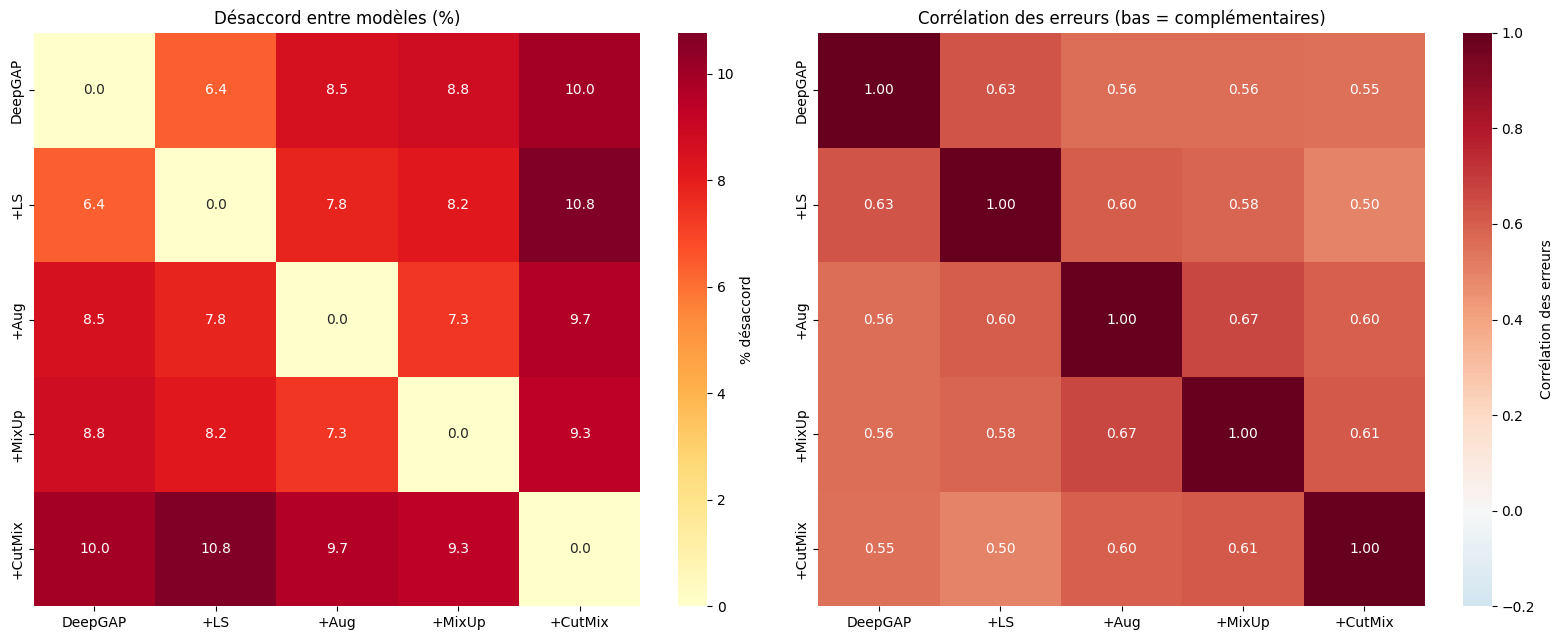

Paires les plus diversifiées :
  +LS          <-> +CutMix        rho = 0.496
  DeepGAP      <-> +CutMix        rho = 0.552
  DeepGAP      <-> +Aug           rho = 0.556
  DeepGAP      <-> +MixUp         rho = 0.558
  +LS          <-> +MixUp         rho = 0.578


In [39]:
names_list = list(all_models.keys())
n = len(names_list)

disagreement = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        disagreement[i, j] = 100 * (model_preds[names_list[i]] != model_preds[names_list[j]]).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
sns.heatmap(disagreement, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=names_list, yticklabels=names_list,
            cbar_kws={'label': '% désaccord'}, ax=ax1)
ax1.set_title('Désaccord entre modèles (%)')

error_masks = [(model_preds[n] != labels_ref).astype(np.float32) for n in names_list]
corr = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        e1, e2 = error_masks[i], error_masks[j]
        corr[i, j] = np.corrcoef(e1, e2)[0, 1] if (e1.std() > 0 and e2.std() > 0) else float(i == j)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=names_list, yticklabels=names_list,
            vmin=-0.2, vmax=1.0, cbar_kws={'label': 'Corrélation des erreurs'}, ax=ax2)
ax2.set_title('Corrélation des erreurs (bas = complémentaires)')
plt.tight_layout();
plt.show()

pairs = [(names_list[i], names_list[j], corr[i, j])
         for i in range(n) for j in range(i + 1, n)]
print('Paires les plus diversifiées :')
for a, b, c in sorted(pairs, key=lambda t: t[2])[:5]:
    print(f'  {a:<12} <-> {b:<12}   rho = {c:.3f}')


## 12.6 - TTA


In [40]:
def tta_predict(model, loader, device, return_probs=False, use_amp=True):
    model.eval().to(device)
    amp_enabled = use_amp and (device == 'cuda')

    def shift_x(t, px):
        return F.pad(t[..., max(0, -px):t.size(-1) - max(0, px)],
                     (max(0, px), max(0, -px), 0, 0), mode='replicate') if px != 0 else t

    tta_fns = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[-1]),
        lambda x: shift_x(x, 6),
        lambda x: shift_x(x, -6),
    ]

    all_probs, all_labels = [], []
    with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            probs_sum = 0.0
            for aug in tta_fns:
                probs_sum = probs_sum + F.softmax(model(aug(images)).float(), dim=1)
            all_probs.append((probs_sum / len(tta_fns)).cpu())
            all_labels.append(labels)

    all_probs = torch.cat(all_probs, dim=0)
    all_labels = torch.cat(all_labels, dim=0).numpy()
    preds = all_probs.argmax(dim=1).numpy()
    accuracy = 100 * (preds == all_labels).sum() / len(all_labels)
    if return_probs:
        return accuracy, preds, all_labels, all_probs.numpy()
    return accuracy, preds, all_labels


print(f'{"Modèle":<22} {"sans TTA":>11} {"avec TTA":>11} {"delta":>8}')
print('-' * 54)
tta_scores = {}
for tag, mdl, base in [
    ('DeepGAPCNN', deep_model, 93.13),
    ('+LS', model_ls, improvements_results.get('LS', 0.0)),
    ('+LS+Aug', model_aug, improvements_results.get('AUG', 0.0)),
    ('+MixUp', model_mixup, improvements_results.get('MIXUP', 0.0)),
    ('+CutMix', model_cutmix, improvements_results.get('CUTMIX', 0.0)),
]:
    acc_tta, _, _ = tta_predict(mdl, testloader, device, use_amp=USE_AMP)
    print(f'{tag:<22} {base:>10.2f}% {acc_tta:>10.2f}% {acc_tta - base:>+7.2f}')
    tta_scores[tag] = acc_tta

improvements_results['TTA_best'] = max(tta_scores.values())


Modèle                    sans TTA    avec TTA    delta
------------------------------------------------------
DeepGAPCNN                  93.13%      92.42%   -0.71
+LS                         92.92%      92.79%   -0.13
+LS+Aug                     90.60%      90.78%   +0.18
+MixUp                      90.57%      91.02%   +0.45
+CutMix                     88.02%      88.52%   +0.50


## 12.7 - Ensembling raisonné

In [41]:
def get_probs(model, loader, device, use_tta=False, use_amp=True):
    if use_tta:
        _, _, labels, probs = tta_predict(model, loader, device, return_probs=True, use_amp=use_amp)
        return probs, labels
    model.eval().to(device)
    amp_enabled = use_amp and (device == 'cuda')
    probs_all, labels_all = [], []
    with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
        for images, labs in loader:
            images = images.to(device, non_blocking=True)
            probs_all.append(F.softmax(model(images).float(), dim=1).cpu().numpy())
            labels_all.append(labs.numpy())
    return np.concatenate(probs_all), np.concatenate(labels_all)


def ensemble_predict(models, loader, device, use_tta=False, weights=None, use_amp=True):
    if weights is None:
        weights = [1.0] * len(models)
    w = np.array(weights, dtype=np.float32);
    w = w / w.sum()
    probs_sum, labels_ref = None, None
    for wi, m in zip(w, models):
        probs, labels = get_probs(m, loader, device, use_tta=use_tta, use_amp=use_amp)
        if probs_sum is None:
            probs_sum, labels_ref = wi * probs, labels
        else:
            probs_sum = probs_sum + wi * probs
    preds = probs_sum.argmax(axis=1)
    accuracy = 100 * (preds == labels_ref).sum() / len(labels_ref)
    return accuracy, preds, labels_ref, probs_sum


In [42]:
ensembles = {
    'E1_strategies': [model_ls, model_aug, model_mixup, model_cutmix],
    'E2_strat+deep': [deep_model, model_ls, model_aug, model_mixup, model_cutmix],
    'E3_full': [deep_model, model_ls, model_aug, model_mixup, model_cutmix],
    'E4_top4': None,
}

indiv_acc = {
    'deep_model': 93.13,
    'model_ls': improvements_results.get('LS', 0),
    'model_aug': improvements_results.get('AUG', 0),
    'model_mixup': improvements_results.get('MIXUP', 0),
    'model_cutmix': improvements_results.get('CUTMIX', 0),
}
top4_names = [n for n, _ in sorted(indiv_acc.items(), key=lambda t: -t[1])[:4]]
ensembles['E4_top4'] = [globals()[n] for n in top4_names]
print(f'Top 4 : {top4_names}')

print(f'\n{"Ensemble":<18} {"N":>3} {"no TTA":>10} {"+ TTA":>10}  {"gain TTA":>10}')
print('-' * 60)
ens_results = {}
for name, mods in ensembles.items():
    acc_no, _, _, _ = ensemble_predict(mods, testloader, device, use_tta=False, use_amp=USE_AMP)
    acc_ta, p_ta, l_ta, pr_ta = ensemble_predict(mods, testloader, device, use_tta=True, use_amp=USE_AMP)
    print(f'{name:<18} {len(mods):>3} {acc_no:>9.2f}% {acc_ta:>9.2f}% {acc_ta - acc_no:>+9.2f}')
    ens_results[name] = {'models': mods, 'acc_noTTA': acc_no, 'acc_TTA': acc_ta,
                         'probs_TTA': pr_ta, 'preds_TTA': p_ta}
    improvements_results[f'{name}_noTTA'] = acc_no
    improvements_results[f'{name}_TTA'] = acc_ta


Top 4 : ['deep_model', 'model_ls', 'model_aug', 'model_mixup']

Ensemble             N     no TTA      + TTA    gain TTA
------------------------------------------------------------
E1_strategies        4     92.58%     92.42%     -0.16
E2_strat+deep        5     93.21%     93.26%     +0.05
E3_full              5     93.21%     93.26%     +0.05
E4_top4              4     93.42%     93.42%     +0.00


In [43]:
print('=' * 65)
print('RÉCAPITULATIF COMPLET')
print('=' * 65)
print(f'{"Configuration":<45} {"Accuracy":>12}')
print('-' * 65)
print(f'{"  DeepGAPCNN":<45} {93.13:>11.2f}%')
for k in ['LS', 'AUG', 'MIXUP', 'CUTMIX']:
    if k in improvements_results:
        print(f'{"  DeepGAPCNN + " + k:<45} {improvements_results[k]:>11.2f}%')
if 'TTA_best' in improvements_results:
    print(f'{"  + TTA (meilleur individuel)":<45} {improvements_results["TTA_best"]:>11.2f}%')
for name in ensembles:
    if f'{name}_noTTA' in improvements_results:
        print(f'{"  " + name + " (no TTA)":<45} {improvements_results[f"{name}_noTTA"]:>11.2f}%')
        print(f'{"  " + name + " (+ TTA)":<45} {improvements_results[f"{name}_TTA"]:>11.2f}%')
print('=' * 65)
best_name = max(improvements_results, key=improvements_results.get)
print(f'\nMeilleure configuration : {best_name} = {improvements_results[best_name]:.2f}%')


RÉCAPITULATIF COMPLET
Configuration                                     Accuracy
-----------------------------------------------------------------
  DeepGAPCNN                                        93.13%
  DeepGAPCNN + LS                                   92.92%
  DeepGAPCNN + AUG                                  90.60%
  DeepGAPCNN + MIXUP                                90.57%
  DeepGAPCNN + CUTMIX                               88.02%
  + TTA (meilleur individuel)                       92.79%
  E1_strategies (no TTA)                            92.58%
  E1_strategies (+ TTA)                             92.42%
  E2_strat+deep (no TTA)                            93.21%
  E2_strat+deep (+ TTA)                             93.26%
  E3_full (no TTA)                                  93.21%
  E3_full (+ TTA)                                   93.26%
  E4_top4 (no TTA)                                  93.42%
  E4_top4 (+ TTA)                                   93.42%

Meilleure configuration : 

## 12.8 - Soumission finale (ensembles v1)

Génère `test.csv` avec le meilleur ensemble trouvé ci-dessus (+ TTA, bf16).


In [44]:
def tta_predict_tensor(model, x, device, batch_size=128, use_amp=True):
    model.eval().to(device)
    amp_enabled = use_amp and (device == 'cuda')

    def shift_x(t, px):
        return F.pad(t[..., max(0, -px):t.size(-1) - max(0, px)],
                     (max(0, px), max(0, -px), 0, 0), mode='replicate') if px != 0 else t

    tta_fns = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[-1]),
        lambda x: shift_x(x, 6),
        lambda x: shift_x(x, -6),
    ]

    probs_all = []
    with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
        for start in range(0, x.size(0), batch_size):
            batch = x[start:start + batch_size].to(device, non_blocking=True)
            probs_sum = 0.0
            for aug in tta_fns:
                probs_sum = probs_sum + F.softmax(model(aug(batch)).float(), dim=1)
            probs_all.append((probs_sum / len(tta_fns)).cpu())
    return torch.cat(probs_all, dim=0).numpy()


def ensemble_predict_tensor(models, x, device, batch_size=128,
                            use_tta=True, weights=None, use_amp=True):
    if weights is None:
        weights = [1.0] * len(models)
    w = np.array(weights, dtype=np.float32);
    w = w / w.sum()
    probs_sum = None
    for wi, m in zip(w, models):
        if use_tta:
            p = tta_predict_tensor(m, x, device, batch_size=batch_size, use_amp=use_amp)
        else:
            m.eval().to(device)
            amp_enabled = use_amp and (device == 'cuda')
            ps = []
            with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
                for start in range(0, x.size(0), batch_size):
                    batch = x[start:start + batch_size].to(device, non_blocking=True)
                    ps.append(F.softmax(m(batch).float(), dim=1).cpu().numpy())
            p = np.concatenate(ps, axis=0)
        probs_sum = wi * p if probs_sum is None else probs_sum + wi * p
    return probs_sum


Ensemble retenu : E4_top4 (4 modèles, TTA)
Accuracy test interne : 93.42%
test.npy shape brute = (4224, 128, 192), dtype = uint8
-> après prétraitement : shape = (4224, 1, 128, 192), dtype = float32, range = [0.000, 1.000]

✓ test.csv écrit (4224 lignes)
   ID  Category
0   0         7
1   1         1
2   2         1
3   3         4
4   4         1
5   5         1
6   6         4
7   7         3
8   8         8
9   9         0


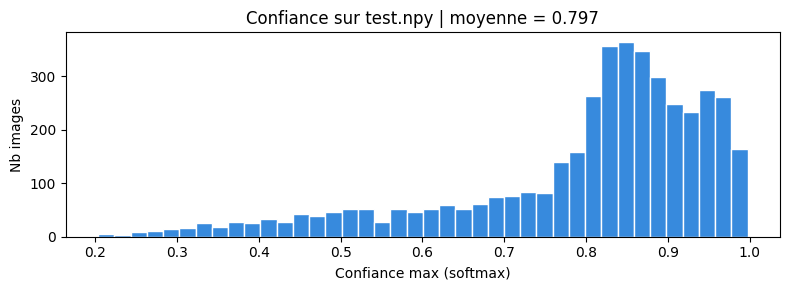

Prédictions confiance < 0.5 : 345 / 4224


In [45]:
best_ens_name = max(ensembles, key=lambda n: ens_results[n]['acc_TTA'])
best_models_v1 = ens_results[best_ens_name]['models']
best_acc_v1 = ens_results[best_ens_name]['acc_TTA']
print(f'Ensemble retenu : {best_ens_name} ({len(best_models_v1)} modèles, TTA)')
print(f'Accuracy test interne : {best_acc_v1:.2f}%')

# Charger + normaliser test.npy
test_images = load_test_npy(TEST_NPY)
if tuple(test_images.shape[-2:]) != (IMG_H, IMG_W):
    test_images = F.interpolate(test_images, size=(IMG_H, IMG_W), mode='bilinear', align_corners=False)
mean_t = torch.tensor(MEAN).view(1, -1, 1, 1)
std_t = torch.tensor(STD).view(1, -1, 1, 1)
test_images_norm = (test_images - mean_t) / std_t

probs_final = ensemble_predict_tensor(best_models_v1, test_images_norm, device,
                                      batch_size=128, use_tta=True, use_amp=USE_AMP)
y_pred_final = probs_final.argmax(axis=1)

submission = pd.DataFrame({'ID': np.arange(len(y_pred_final)),
                           'Category': y_pred_final.astype(int)})
submission.to_csv('test.csv', index=False)
print(f'\n✓ test.csv écrit ({len(submission)} lignes)')
print(submission.head(10))

max_p = probs_final.max(axis=1)
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(max_p, bins=40, color='#378ADD', edgecolor='white')
ax.set_xlabel('Confiance max (softmax)');
ax.set_ylabel('Nb images')
ax.set_title(f'Confiance sur test.npy | moyenne = {max_p.mean():.3f}')
plt.tight_layout();
plt.show()
print(f'Prédictions confiance < 0.5 : {(max_p < 0.5).sum()} / {len(max_p)}')


# 13 - Piste A d'amélioration : densifier l'architecture + multi-seed


In [46]:
def train_model_largebatch(model, trainloader, valloader, num_epochs=40,
                           base_lr=2e-3, warmup_epochs=8, weight_decay=1e-4,
                           device='cpu', model_name='model',
                           class_weights=None, label_smoothing=0.1,
                           mix_mode=None, mix_alpha=0.2,
                           patience=20, use_amp=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    val_criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, num_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    amp_enabled = use_amp and (device == 'cuda')

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state, epochs_no_imp = 0.0, None, 0
    t0 = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in trainloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            mix_this = {'mixup': 'mixup', 'cutmix': 'cutmix'}.get(mix_mode)
            if mix_mode == 'both':
                mix_this = 'mixup' if np.random.rand() < 0.5 else 'cutmix'

            with torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
                if mix_this == 'mixup':
                    mixed, y_a, y_b, lam = mixup_data(images, labels, mix_alpha)
                    outputs = model(mixed)
                    loss = lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)
                elif mix_this == 'cutmix':
                    mixed, y_a, y_b, lam = cutmix_data(images, labels, mix_alpha)
                    outputs = model(mixed)
                    loss = lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, pred = outputs.max(1)
            if mix_this is not None:
                correct += (lam * (pred == y_a).float()
                            + (1.0 - lam) * (pred == y_b).float()).sum().item()
            else:
                correct += (pred == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=amp_enabled):
            for images, labels in valloader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = val_criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_loss = val_loss / val_total
        val_acc = 100 * val_correct / val_total

        scheduler.step()
        for k, v in [('train_loss', train_loss), ('train_acc', train_acc),
                     ('val_loss', val_loss), ('val_acc', val_acc)]:
            history[k].append(v)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_imp = 0
        else:
            epochs_no_imp += 1

        phase = 'warmup' if epoch < warmup_epochs else 'cosine'
        marker = '  *' if improved else ''
        print(f'[{model_name}] ep {epoch + 1:2d}/{num_epochs} ({phase:6}) | '
              f'train loss={train_loss:.4f} acc={train_acc:5.2f}% | '
              f'val loss={val_loss:.4f} acc={val_acc:5.2f}% | '
              f'lr={scheduler.get_last_lr()[0]:.5f}{marker}')

        if epochs_no_imp >= patience:
            print(f'  -> Early stopping epoch {epoch + 1}')
            break

    print(f'\n[{model_name}] {time.time() - t0:.1f}s | best val = {best_val_acc:.2f}%')
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_state


## 13.1 - DeepGAPCNN v2 : densifié mais pas trop

In [47]:
class ConvBlockV2(nn.Module):
    def __init__(self, in_c, out_c, pool=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.pool = nn.MaxPool2d(2, 2) if pool else nn.Identity()

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.pool(x)


class DeepGAPCNN_v2(nn.Module):
    def __init__(self, num_classes=10, in_channels=1, dropout=0.4):
        super().__init__()
        self.block1 = ConvBlockV2(in_channels, 64)
        self.block2 = ConvBlockV2(64, 128)
        self.block3 = ConvBlockV2(128, 256)
        self.block4 = ConvBlockV2(256, 384)
        self.block5 = ConvBlockV2(384, 512)
        self.block6 = ConvBlockV2(512, 512, pool=False)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        for block in [self.block1, self.block2, self.block3,
                      self.block4, self.block5, self.block6]:
            x = block(x)
        return self.fc(self.dropout(torch.flatten(self.gap(x), 1)))


m_test = DeepGAPCNN_v2()
with torch.no_grad():
    y = m_test(torch.randn(2, 1, IMG_H, IMG_W))
n_layers = sum(1 for m in m_test.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))
print(f'Output : {tuple(y.shape)} | params : {count_params(m_test):,} | couches : {n_layers}')


Output : (2, 10) | params : 12,215,114 | couches : 13


## 13.2 - Est-ce que la densification rend l'augmentation utile ?


In [48]:
print('=' * 70)
print('13.2a - DeepGAPCNN_v2 baseline + LS')
print('=' * 70)

model_v2_base = DeepGAPCNN_v2(num_classes=NUM_CLASSES, in_channels=1, dropout=0.4)
hist_v2_base, _ = train_model_largebatch(
    model_v2_base, trainloader, valloader,
    num_epochs=120, base_lr=2e-3, warmup_epochs=8, weight_decay=1e-4,
    device=device, model_name='DeepGAPv2',
    class_weights=class_weights, label_smoothing=0.1,
    mix_mode=None, patience=10, use_amp=USE_AMP,
)
acc_v2_base, _, _ = evaluate(model_v2_base, testloader, device)
print(f'\n*** DeepGAPCNN_v2 baseline = {acc_v2_base:.2f}%  (v1 baseline = 93.13%) ***')

improvements_results['V2_BASE'] = acc_v2_base
improvements_models['V2_BASE'] = model_v2_base
#torch.save(model_v2_base.state_dict(), 'model_DeepGAPv2_base.pth')


13.2a - DeepGAPCNN_v2 baseline + LS
[DeepGAPv2] ep  1/120 (warmup) | train loss=1.8152 acc=45.89% | val loss=1.6883 acc=40.26% | lr=0.00050  *
[DeepGAPv2] ep  2/120 (warmup) | train loss=1.3809 acc=65.65% | val loss=1.4194 acc=52.50% | lr=0.00075  *
[DeepGAPv2] ep  3/120 (warmup) | train loss=1.1902 acc=74.68% | val loss=1.4687 acc=49.76% | lr=0.00100
[DeepGAPv2] ep  4/120 (warmup) | train loss=1.0897 acc=79.05% | val loss=1.2222 acc=63.56% | lr=0.00125  *
[DeepGAPv2] ep  5/120 (warmup) | train loss=1.0215 acc=82.16% | val loss=1.0599 acc=68.46% | lr=0.00150  *
[DeepGAPv2] ep  6/120 (warmup) | train loss=0.9683 acc=84.34% | val loss=1.1511 acc=64.43% | lr=0.00175
[DeepGAPv2] ep  7/120 (warmup) | train loss=0.9278 acc=86.08% | val loss=1.7108 acc=47.16% | lr=0.00200
[DeepGAPv2] ep  8/120 (warmup) | train loss=0.9024 acc=86.91% | val loss=1.1111 acc=66.30% | lr=0.00200
[DeepGAPv2] ep  9/120 (cosine) | train loss=0.8499 acc=89.16% | val loss=0.5784 acc=86.18% | lr=0.00200  *
[DeepGAPv2] e

In [49]:
print('=' * 70)
print('13.2b - DeepGAPCNN_v2 + LS + Strong Aug + MixUp')
print('=' * 70)

model_v2_mix = DeepGAPCNN_v2(num_classes=NUM_CLASSES, in_channels=1, dropout=0.3)
hist_v2_mix, _ = train_model_largebatch(
    model_v2_mix, trainloader_strong, valloader,
    num_epochs=120, base_lr=2e-3, warmup_epochs=8, weight_decay=1e-4,
    device=device, model_name='DeepGAPv2+MIX',
    class_weights=class_weights, label_smoothing=0.1,
    mix_mode='mixup', mix_alpha=0.2,
    patience=20, use_amp=USE_AMP,
)
acc_v2_mix, _, _ = evaluate(model_v2_mix, testloader, device)
print(f'\n*** DeepGAPCNN_v2 + MixUp = {acc_v2_mix:.2f}% ***')
print(f'    v2_base = {improvements_results["V2_BASE"]:.2f}%')
print(f'    delta   = {acc_v2_mix - improvements_results["V2_BASE"]:+.2f} pt')

improvements_results['V2_MIX'] = acc_v2_mix
improvements_models['V2_MIX'] = model_v2_mix
#torch.save(model_v2_mix.state_dict(), 'model_DeepGAPv2_mix.pth')


13.2b - DeepGAPCNN_v2 + LS + Strong Aug + MixUp
[DeepGAPv2+MIX] ep  1/120 (warmup) | train loss=2.1422 acc=28.20% | val loss=1.8881 acc=38.07% | lr=0.00050  *
[DeepGAPv2+MIX] ep  2/120 (warmup) | train loss=1.8237 acc=46.14% | val loss=1.5680 acc=47.02% | lr=0.00075  *
[DeepGAPv2+MIX] ep  3/120 (warmup) | train loss=1.6121 acc=56.71% | val loss=0.9842 acc=68.38% | lr=0.00100  *
[DeepGAPv2+MIX] ep  4/120 (warmup) | train loss=1.6705 acc=55.47% | val loss=1.2582 acc=59.79% | lr=0.00125
[DeepGAPv2+MIX] ep  5/120 (warmup) | train loss=1.5232 acc=61.93% | val loss=1.5225 acc=53.00% | lr=0.00150
[DeepGAPv2+MIX] ep  6/120 (warmup) | train loss=1.4360 acc=65.70% | val loss=1.1336 acc=65.40% | lr=0.00175
[DeepGAPv2+MIX] ep  7/120 (warmup) | train loss=1.2926 acc=71.62% | val loss=1.0720 acc=65.69% | lr=0.00200
[DeepGAPv2+MIX] ep  8/120 (warmup) | train loss=1.3884 acc=68.89% | val loss=1.0466 acc=70.72% | lr=0.00200  *
[DeepGAPv2+MIX] ep  9/120 (cosine) | train loss=1.2784 acc=72.62% | val loss

## 13.3 - Multi-seed deep ensemble


In [ ]:
if improvements_results.get('V2_MIX', 0) >= improvements_results.get('V2_BASE', 0):
    best_v2_config = 'MIX'
    best_v2_acc = improvements_results['V2_MIX']
    best_v2_model = model_v2_mix
    use_mix = True
    use_strong_aug = True
else:
    best_v2_config = 'BASE'
    best_v2_acc = improvements_results['V2_BASE']
    best_v2_model = model_v2_base
    use_mix = False
    use_strong_aug = False

print(f'Config v2 retenue : +{best_v2_config} ({best_v2_acc:.2f}%)')

loader_for_train = trainloader_strong if use_strong_aug else trainloader
mix_mode_train = 'mixup' if use_mix else None

SEEDS = [123, 2024, 7, 999]
v2_ensemble = [best_v2_model]

for seed in SEEDS:
    print('=' * 70)
    print(f'13.3 - DeepGAPCNN_v2 seed={seed}  (config {best_v2_config})')
    print('=' * 70)

    torch.manual_seed(seed)
    np.random.seed(seed)

    m = DeepGAPCNN_v2(num_classes=NUM_CLASSES, in_channels=1, dropout=0.3)
    hist, _ = train_model_largebatch(
        m, loader_for_train, valloader,
        num_epochs=NUM_EPOCHS + 10 if use_mix else NUM_EPOCHS,
        base_lr=LR, weight_decay=WEIGHT_DECAY, warmup_epochs=WARMUP_EPOCHS,
        device=device, model_name=f'DeepGAPv2_s{seed}',
        class_weights=class_weights, label_smoothing=0.1,
        mix_mode=mix_mode_train, mix_alpha=0.2,
        patience=30, use_amp=USE_AMP,
    )
    acc, _, _ = evaluate(m, testloader, device)
    print(f'  seed {seed} : test acc = {acc:.2f}%')

    v2_ensemble.append(m)
    improvements_models[f'V2_s{seed}'] = m
    improvements_results[f'V2_s{seed}'] = acc
    #torch.save(m.state_dict(), f'model_DeepGAPv2_s{seed}.pth')

torch.manual_seed(SEED);
np.random.seed(SEED)


Config v2 retenue : +MIX (96.92%)
13.3 - DeepGAPCNN_v2 seed=123  (config MIX)
[DeepGAPv2_s123] ep  1/130 (warmup) | train loss=2.1548 acc=28.42% | val loss=1.6100 acc=42.58% | lr=0.00050  *
[DeepGAPv2_s123] ep  2/130 (warmup) | train loss=1.8832 acc=44.39% | val loss=1.2346 acc=59.11% | lr=0.00075  *


## 13.4 - Évaluation et soumission finale


In [53]:
print('=' * 70)
print('Ensemble multi-seed v2 (5 modèles)')
print('=' * 70)

indiv_accs = [best_v2_acc] + [improvements_results[f'V2_s{s}'] for s in SEEDS]
print('Accuracies individuelles :')
for i, acc in enumerate(indiv_accs):
    name = 'seed_orig' if i == 0 else f'seed_{SEEDS[i - 1]}'
    print(f'  {name:<12} : {acc:.2f}%')
print(f'  moyenne    : {np.mean(indiv_accs):.2f}%')
print(f'  std        : {np.std(indiv_accs):.2f}%')

acc_ens_v2, _, _, _ = ensemble_predict(v2_ensemble, testloader, device,
                                       use_tta=False, use_amp=USE_AMP)
acc_ens_v2_tta, preds_v2, _, probs_v2 = ensemble_predict(v2_ensemble, testloader, device,
                                                         use_tta=True, use_amp=USE_AMP)

print(f'\n  Ensemble v2 (no TTA) : {acc_ens_v2:.2f}%')
print(f'  Ensemble v2 (+ TTA)  : {acc_ens_v2_tta:.2f}%')
print(f'  Gain vs meilleur seul: +{acc_ens_v2_tta - max(indiv_accs):.2f} pt')

improvements_results['V2_ENS_noTTA'] = acc_ens_v2
improvements_results['V2_ENS_TTA'] = acc_ens_v2_tta

# Corrélation d'erreurs entre seeds
print("\n--- Corrélation d'erreurs entre seeds ---")
preds_per_seed = []
for m in v2_ensemble:
    p, lab = get_predictions(m, testloader, device, use_amp=USE_AMP)
    preds_per_seed.append(p)
labels_v2_ref = lab

error_masks = [(p != labels_v2_ref).astype(np.float32) for p in preds_per_seed]
corrs = [
    np.corrcoef(error_masks[i], error_masks[j])[0, 1]
    for i in range(len(error_masks))
    for j in range(i + 1, len(error_masks))
    if error_masks[i].std() > 0 and error_masks[j].std() > 0
]
print(f"Corrélation d'erreurs moyenne : {np.mean(corrs):.3f}")

Ensemble multi-seed v2 (5 modèles)
Accuracies individuelles :
  seed_orig    : 96.92%
  seed_123     : 96.76%
  seed_2024    : 96.81%
  seed_7       : 96.95%
  seed_999     : 96.76%
  moyenne    : 96.84%
  std        : 0.08%

  Ensemble v2 (no TTA) : 97.39%
  Ensemble v2 (+ TTA)  : 97.37%
  Gain vs meilleur seul: +0.42 pt

--- Corrélation d'erreurs entre seeds ---
Corrélation d'erreurs moyenne : 0.610


In [54]:
# Soumission finale
print(f'Ensemble final : {len(v2_ensemble)} modèles v2 + TTA')
print(f'Accuracy test interne : {improvements_results["V2_ENS_TTA"]:.2f}%')

probs_submit = ensemble_predict_tensor(v2_ensemble, test_images_norm, device,
                                       batch_size=128, use_tta=True, use_amp=USE_AMP)
y_pred_submit = probs_submit.argmax(axis=1)

submission = pd.DataFrame({'ID': np.arange(len(y_pred_submit)),
                           'Category': y_pred_submit.astype(int)})
#submission.to_csv('test_big.csv', index=False)
print(f'\n✓ test_big.csv écrit ({len(submission)} lignes)')
print(submission.head(10))


Ensemble final : 5 modèles v2 + TTA
Accuracy test interne : 97.37%

✓ test_big.csv écrit (4224 lignes)
   ID  Category
0   0         5
1   1         1
2   2         1
3   3         4
4   4         8
5   5         1
6   6         4
7   7         3
8   8         8
9   9         0
